# Story 1: planetary-dominated reference eddies

Select stable deep-water AE and CE examples that establish the background polarity-dependent tilt. Under the corrected signed-PV convention, AEs are expected to tilt along signed $\nabla PV$ and CEs opposite it. These are reference states, not examples of every offshore eddy.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
HERE = Path.cwd().resolve()
ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ROOT is None: raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subfolder.')
for path in (ROOT, ROOT / 'case_studies'):
    if str(path) not in sys.path: sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
from paper_case_study_tools import PaperCaseConfig, plot_paper_case, rank_planetary_reference_cases, select_ranked_cases
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)

## Load and classify

Core-mean bathymetry and gradients are used. The main regime requires planetary dominance by at least 2:1 and depth of at least 3,000 m. Bearings with tilt distance below 5 km are excluded from directional ranking.

In [2]:
config = PaperCaseConfig()
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)
df_case, ranking = rank_planetary_reference_cases(df_eddies, config)
display(ranking.groupby('Cyc')['eligible'].agg(candidates='size', eligible='sum'))

,candidates,eligible
Cyc,,
AE,1446,25
CE,1536,5


## Population context

The case figures should accompany this complete-population distribution. A low polarity-aware error means AE alignment or CE opposition, as appropriate.

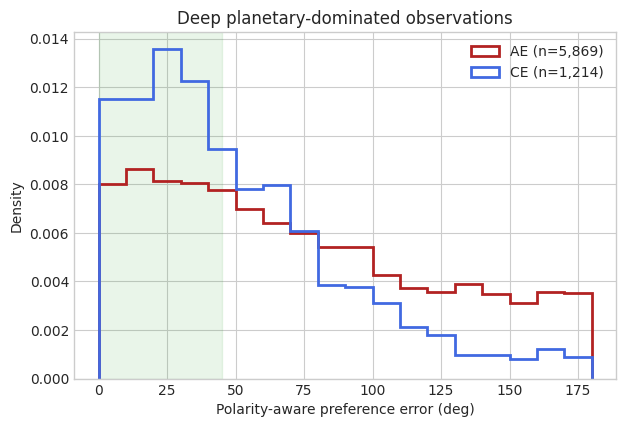

In [3]:
use = df_case[df_case.planetary_regime & df_case.direction_valid]
bins = np.arange(0, 181, 10)
fig, ax = plt.subplots(figsize=(7, 4.5))
for cyc, color in [('AE', 'firebrick'), ('CE', 'royalblue')]:
    values = use.loc[use.Cyc.eq(cyc), 'preference_error_deg']
    ax.hist(values, bins=bins, density=True, histtype='step', lw=2, color=color, label=f'{cyc} (n={len(values):,})')
ax.axvspan(0, config.angle_tolerance_deg, color='tab:green', alpha=.1)
ax.set(xlabel='Polarity-aware preference error (deg)', ylabel='Density', title='Deep planetary-dominated observations')
ax.legend(frameon=False);

## Ranked candidates

The score rewards sustained expected orientation, small typical error, long planetary episodes, data coverage, lifetime and visible tilt magnitude. Ranking is separate for AE and CE.

In [4]:
columns = ['Eddy','Cyc','Region','case_score','lifetime_days','regime_observations','regime_fraction','longest_regime_run','matching_fraction','longest_matching_run','median_preference_error_deg','preference_resultant','directional_coverage','median_tilt_km','median_depth_m']
for cyc in ['AE','CE']:
    print(f'\n{cyc} planetary references')
    display(ranking.loc[(ranking.Cyc.eq(cyc)) & ranking.eligible, columns].head(20).round(3))


AE planetary references


,Eddy,Cyc,Region,case_score,lifetime_days,regime_observations,regime_fraction,longest_regime_run,matching_fraction,longest_matching_run,median_preference_error_deg,preference_resultant,directional_coverage,median_tilt_km,median_depth_m
0,1912,AE,D1,0.761,84.0,78,0.918,78,0.551,12,42.559,0.634,0.929,20.670,4858.135
1,306,AE,D1,0.759,61.0,31,0.500,31,0.774,17,36.488,0.874,0.903,19.406,4863.057
2,107,AE,D1,0.759,54.0,45,0.818,45,0.711,32,28.924,0.596,0.891,18.178,4870.557
3,604,AE,D1,0.756,138.0,79,0.568,79,0.342,14,48.397,0.916,0.957,18.497,4852.546
4,478,AE,D1,0.750,55.0,33,0.589,20,0.727,20,31.462,0.670,0.893,12.362,4850.169
5,2509,AE,D1,0.746,56.0,39,0.684,39,0.615,21,28.820,0.721,0.877,8.989,4853.033
6,1616,AE,D1,0.743,109.0,67,0.609,55,0.388,16,77.196,0.105,0.945,17.769,4831.543
7,267,AE,D1,0.737,52.0,38,0.717,34,0.474,17,48.841,0.804,0.887,21.349,4638.029
8,324,AE,D1,0.733,120.0,83,0.686,74,0.265,12,79.447,0.241,0.950,10.391,4860.856
9,2888,AE,U1,0.730,49.0,36,0.720,31,0.500,15,45.242,0.214,0.860,21.989,4811.707



CE planetary references


,Eddy,Cyc,Region,case_score,lifetime_days,regime_observations,regime_fraction,longest_regime_run,matching_fraction,longest_matching_run,median_preference_error_deg,preference_resultant,directional_coverage,median_tilt_km,median_depth_m
1446,1124,CE,D1,0.701,41.0,22,0.524,22,0.545,6,42.209,0.930,0.857,9.527,4871.588
1447,1680,CE,D1,0.695,34.0,25,0.714,25,0.800,11,27.606,0.950,0.829,16.990,4857.105
1448,84,CE,D1,0.693,31.0,17,0.531,17,1.000,17,13.701,0.978,0.812,39.558,4856.469
1449,1772,CE,D1,0.674,32.0,27,0.818,27,0.481,9,59.757,0.864,0.818,7.470,4876.022
1450,2846,CE,D1,0.661,30.0,20,0.645,20,0.400,8,66.937,0.496,0.806,6.390,4873.436


In [5]:
selected = select_ranked_cases(ranking, 'Cyc', n_per_group=3)
selected

{'AE': [1912, 306, 107], 'CE': [1124, 1680, 84]}

## Candidate figures

Blue background shading marks qualifying planetary-reference days. Retain one final AE and one final CE after visual inspection; the remaining candidates provide robustness and alternatives.

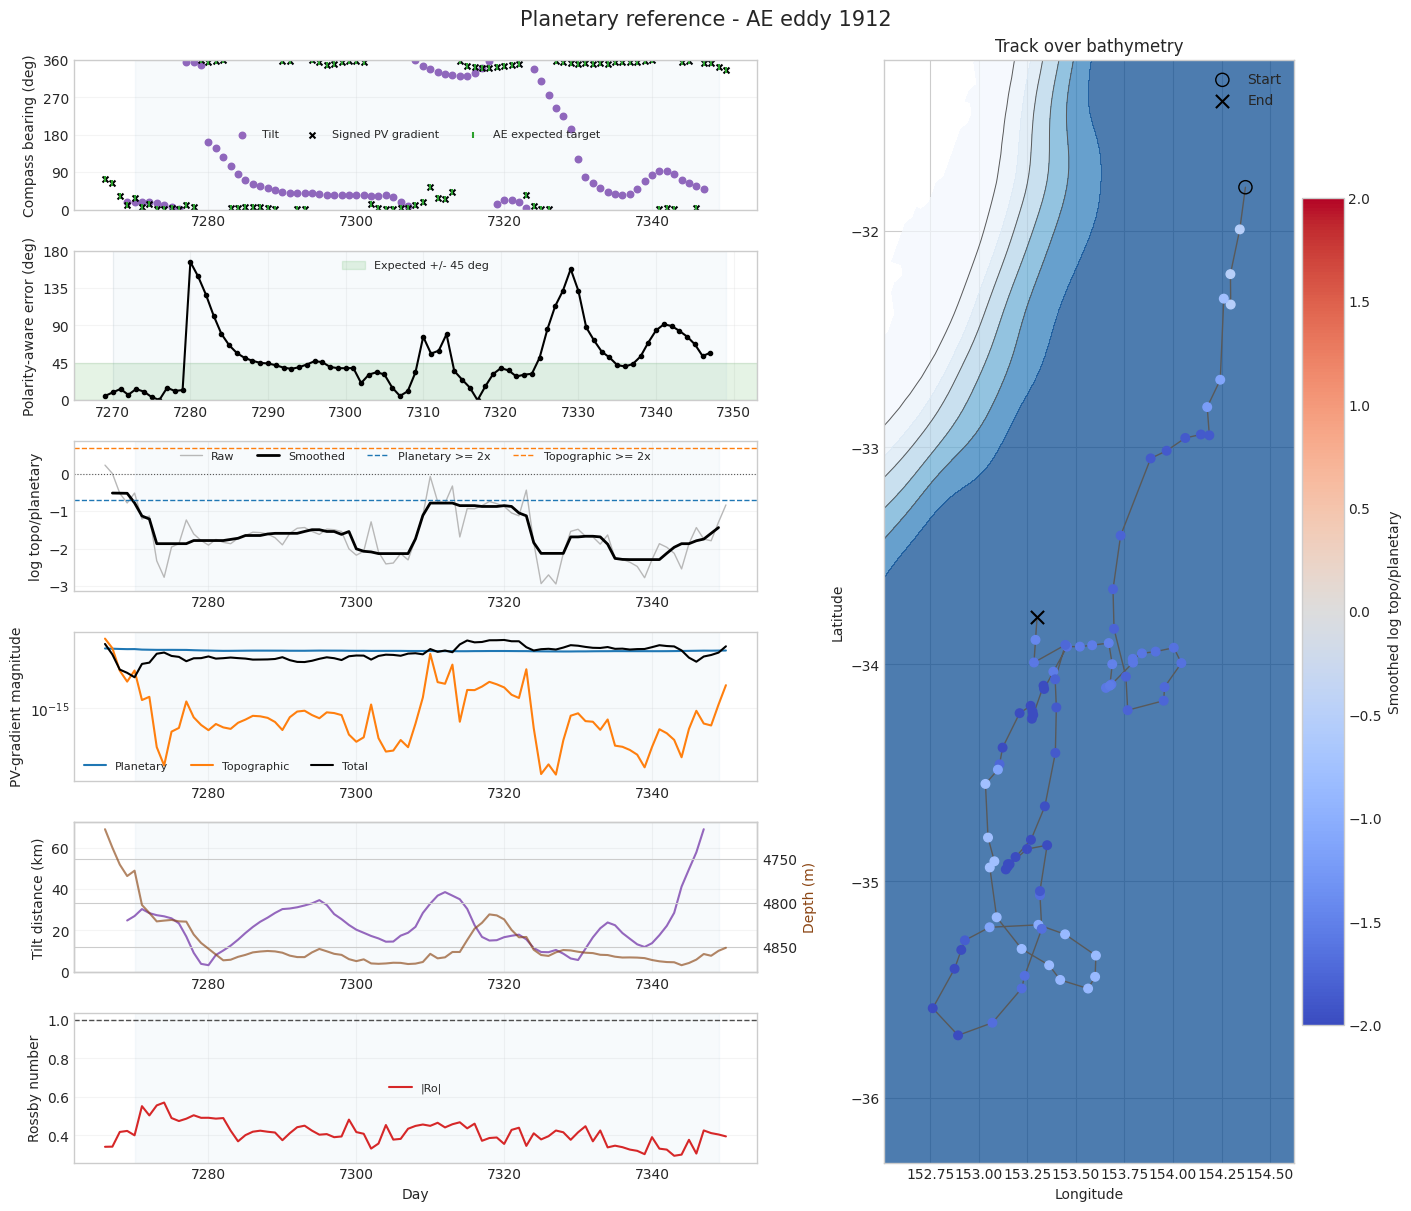

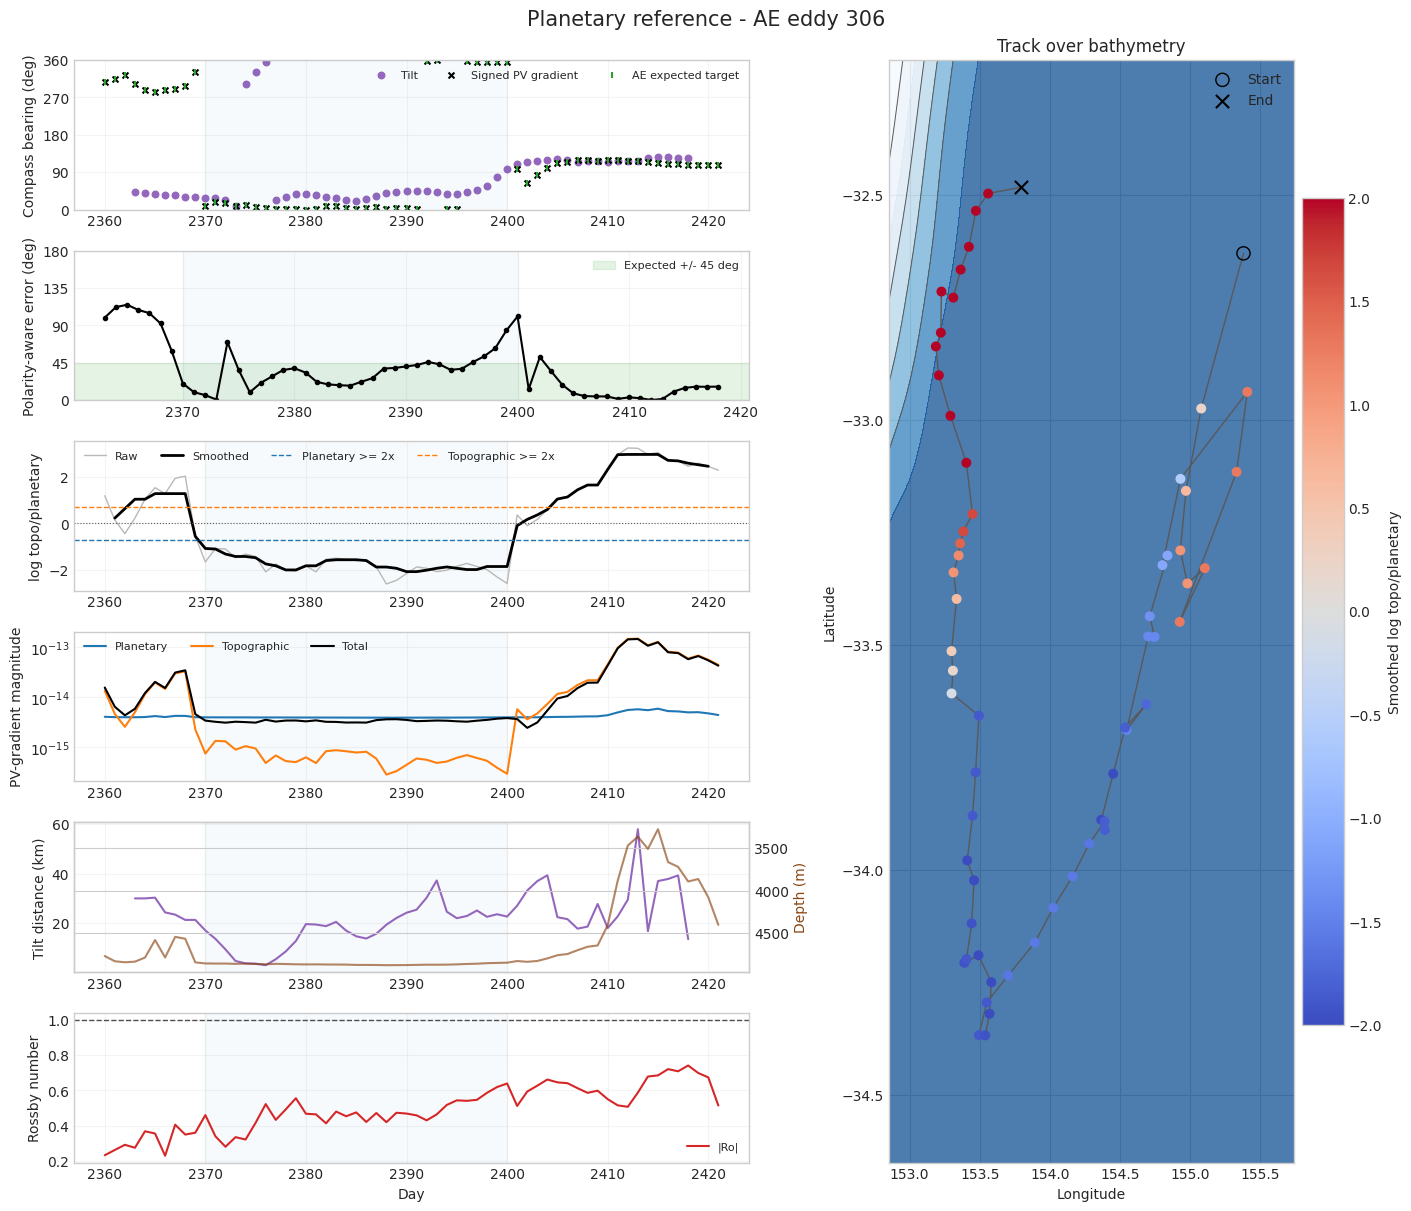

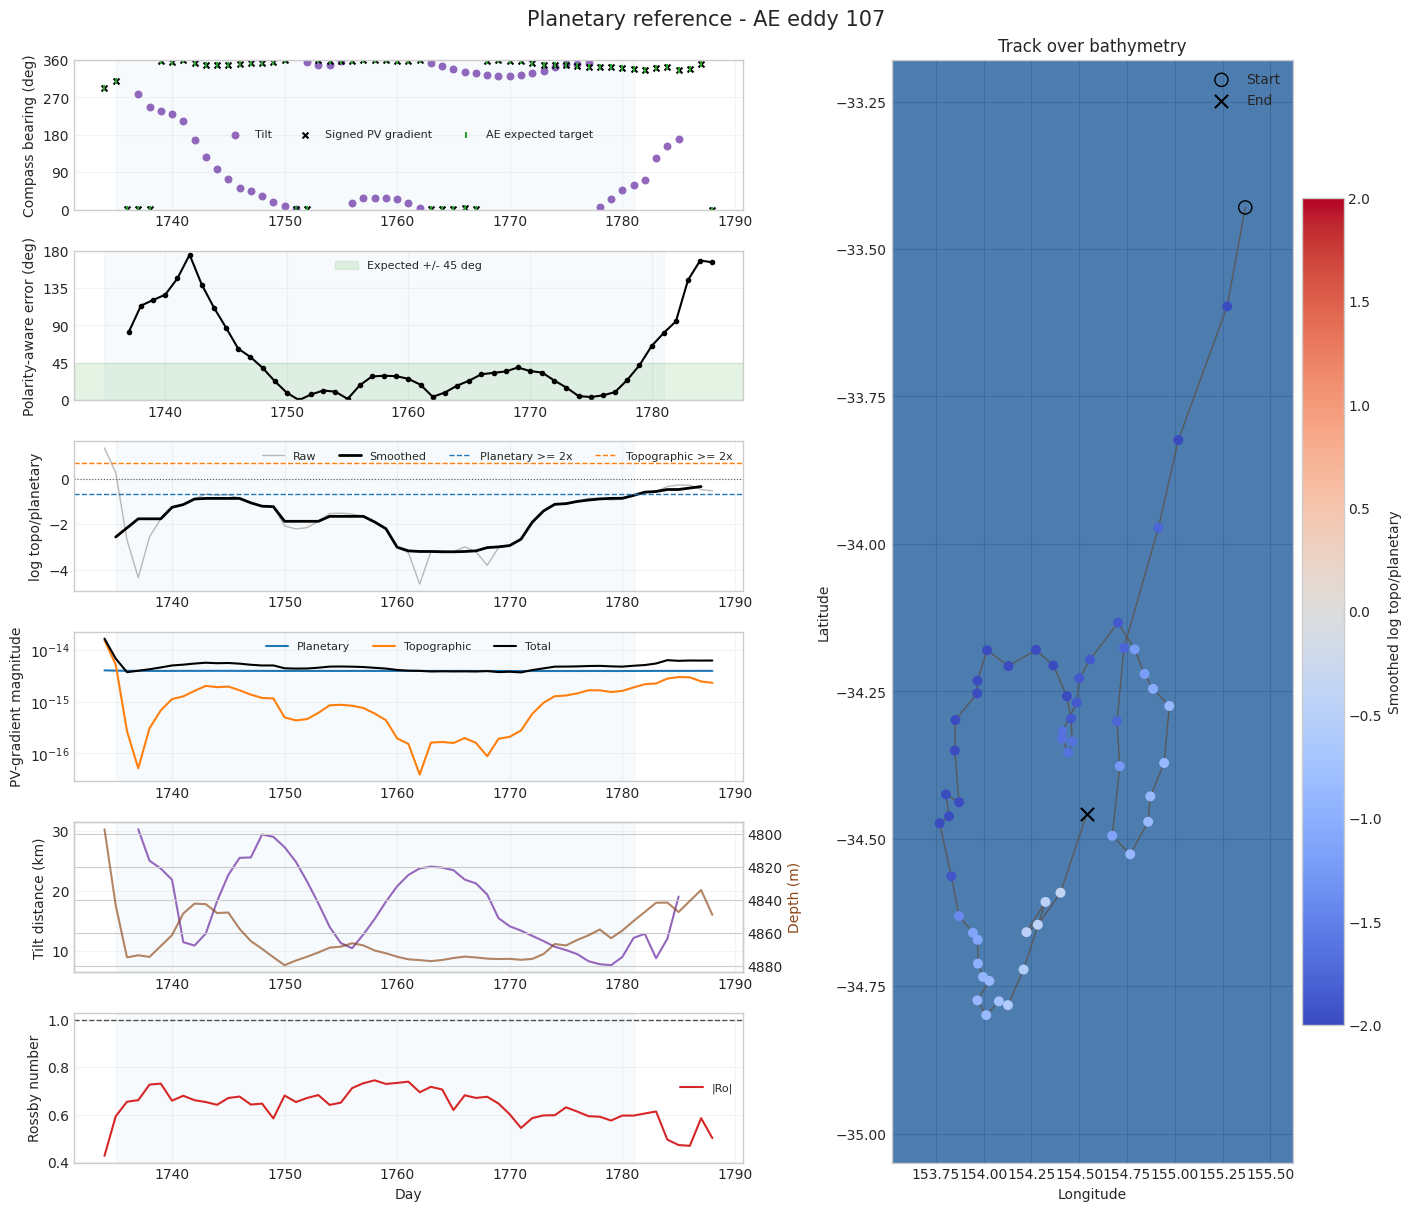

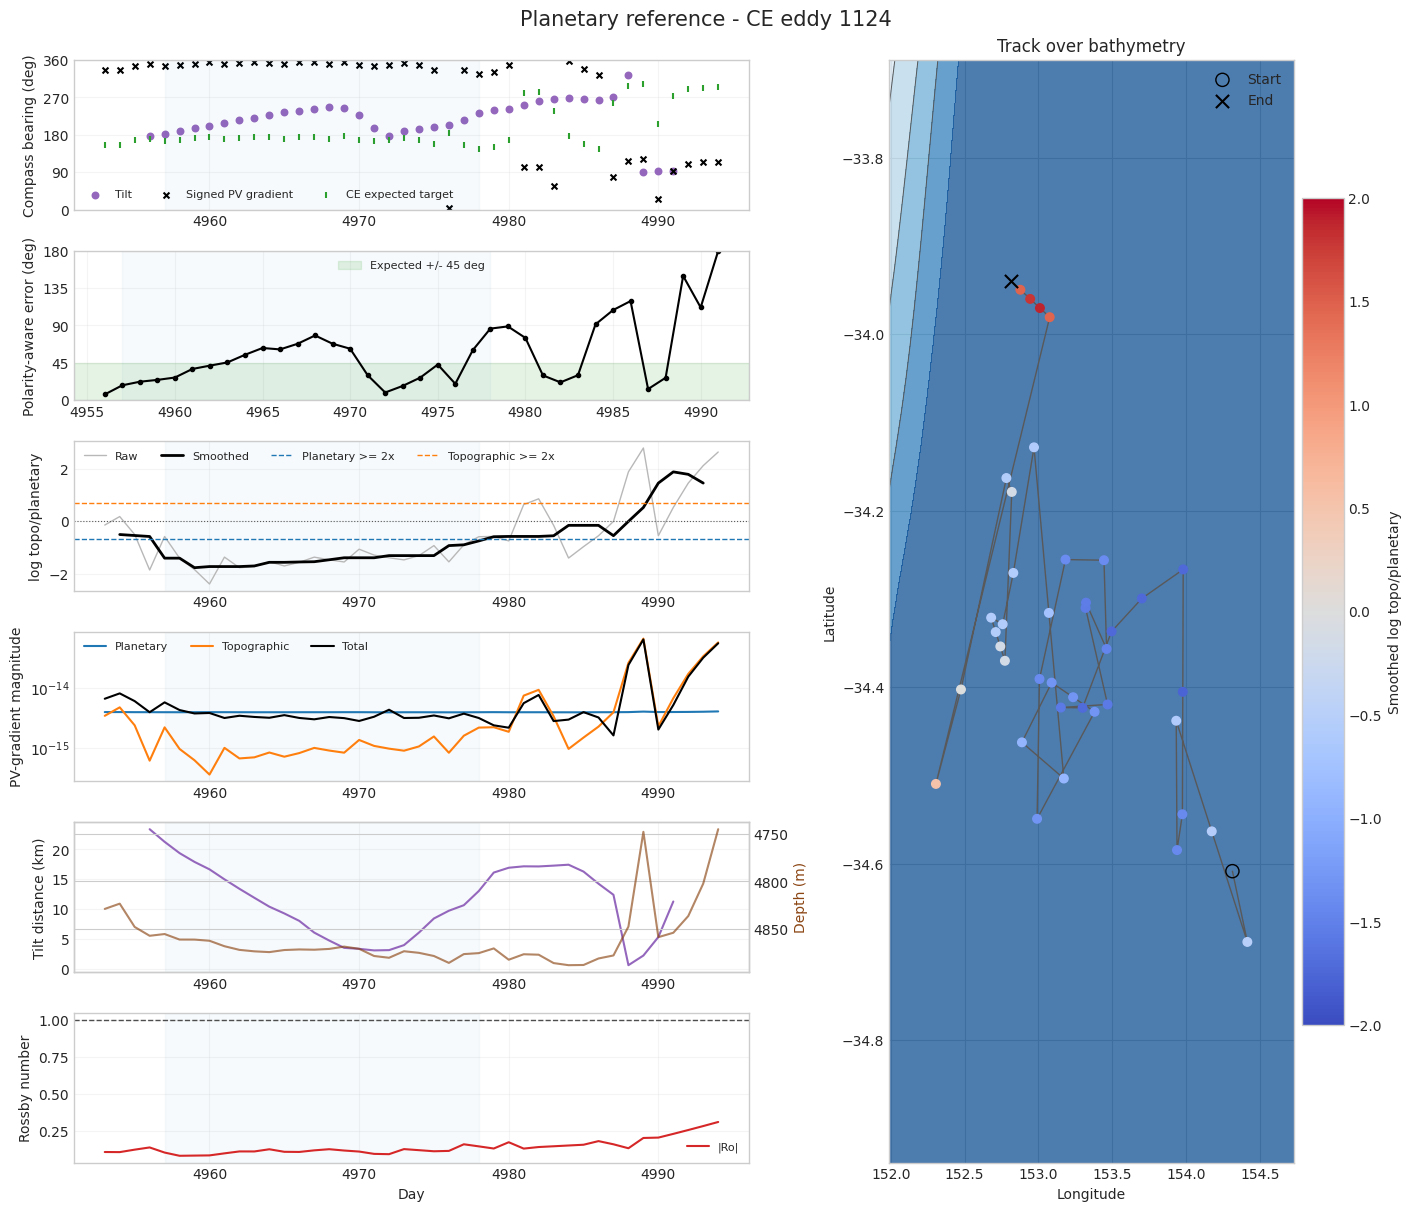

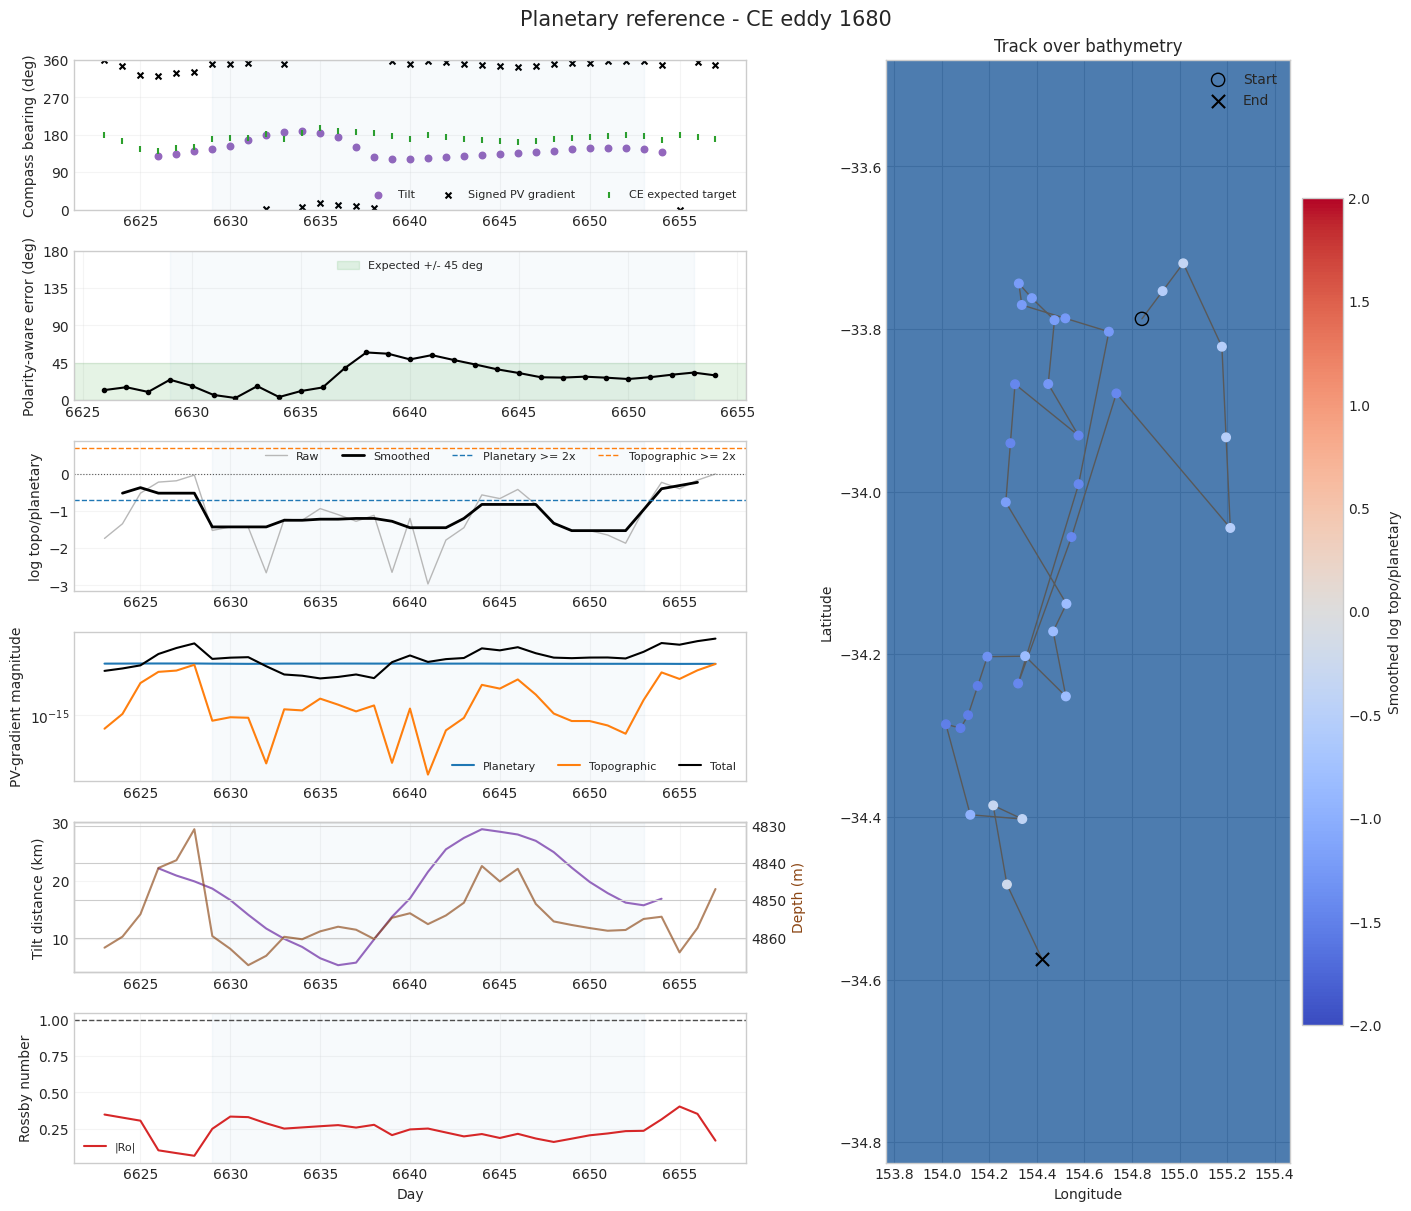

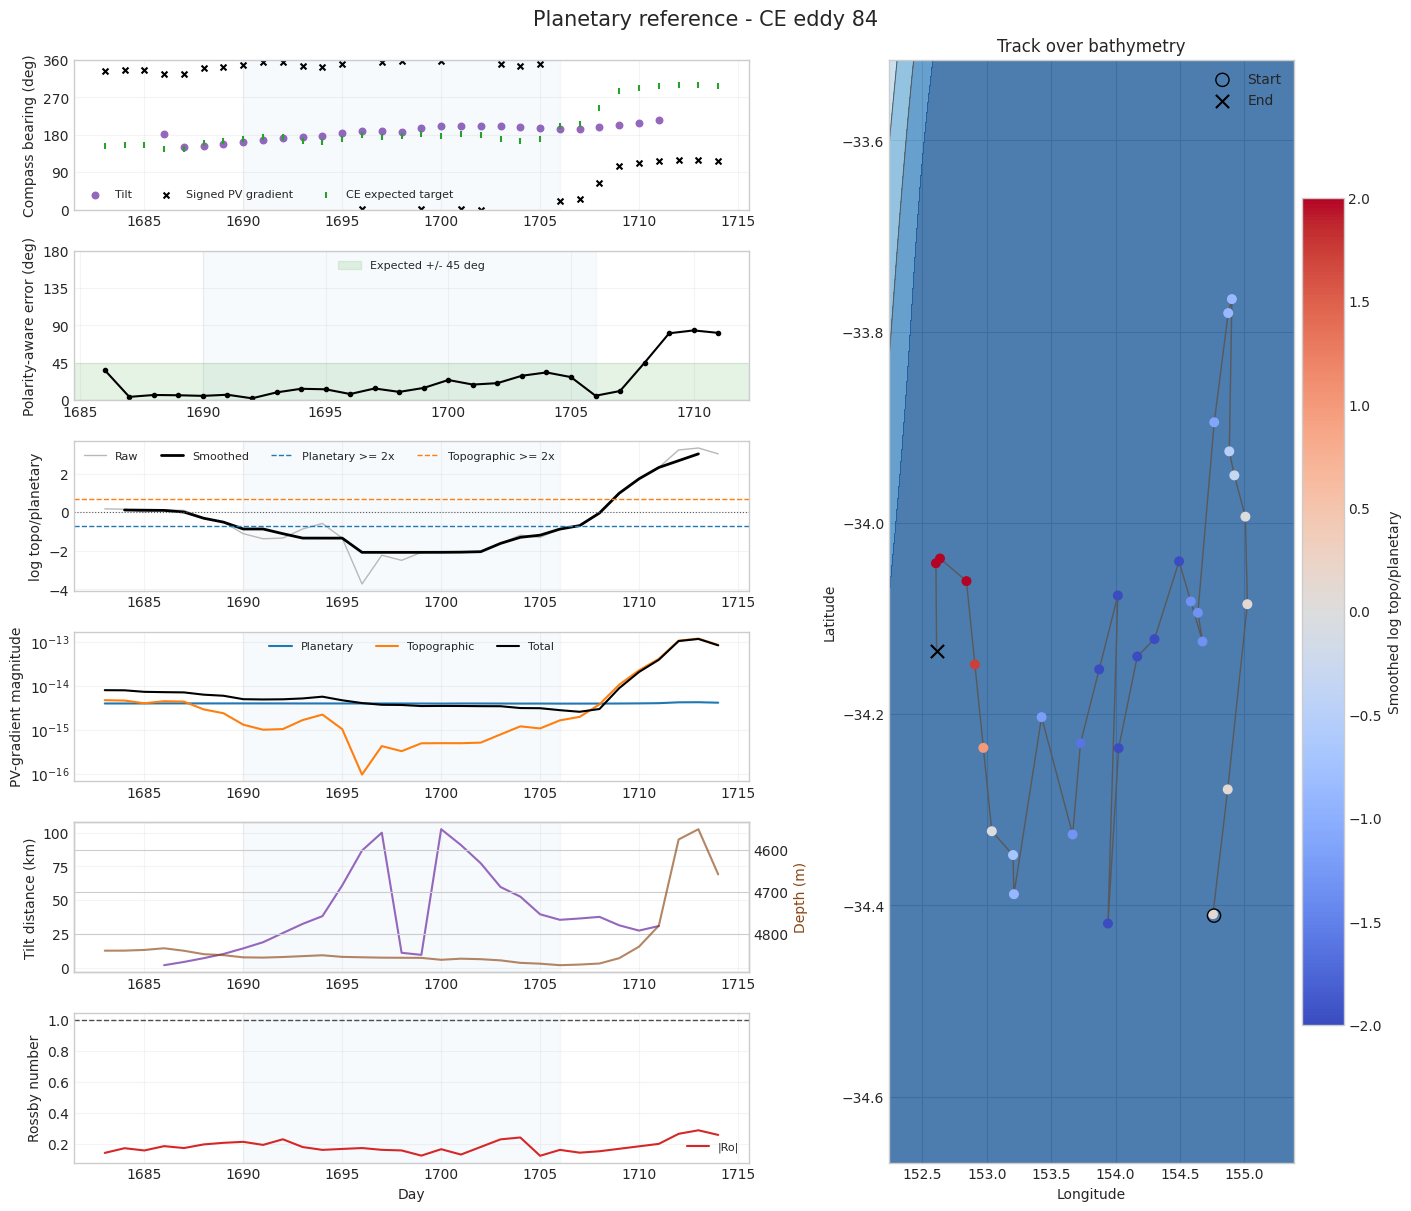

In [6]:
for cyc, eddies in selected.items():
    for eddy_id in eddies:
        track = df_case[df_case.Eddy.eq(eddy_id)]
        plot_paper_case(track, grid, config=config, title=f'Planetary reference - {cyc} eddy {eddy_id}')
        plt.show()

## Selected-case audit

Use this table in decision-making, not as inferential statistics. Daily observations within an eddy are repeated measurements.

In [7]:
selected_ids = [eddy for values in selected.values() for eddy in values]
display(ranking[ranking.Eddy.isin(selected_ids)][columns].sort_values(['Cyc','case_score'], ascending=[True,False]).round(3))

,Eddy,Cyc,Region,case_score,lifetime_days,regime_observations,regime_fraction,longest_regime_run,matching_fraction,longest_matching_run,median_preference_error_deg,preference_resultant,directional_coverage,median_tilt_km,median_depth_m
0,1912,AE,D1,0.761,84.0,78,0.918,78,0.551,12,42.559,0.634,0.929,20.670,4858.135
1,306,AE,D1,0.759,61.0,31,0.500,31,0.774,17,36.488,0.874,0.903,19.406,4863.057
2,107,AE,D1,0.759,54.0,45,0.818,45,0.711,32,28.924,0.596,0.891,18.178,4870.557
1446,1124,CE,D1,0.701,41.0,22,0.524,22,0.545,6,42.209,0.930,0.857,9.527,4871.588
1447,1680,CE,D1,0.695,34.0,25,0.714,25,0.800,11,27.606,0.950,0.829,16.990,4857.105
1448,84,CE,D1,0.693,31.0,17,0.531,17,1.000,17,13.701,0.978,0.812,39.558,4856.469


## Interpretation guardrails

A final reference case should remain offshore, have one sustained planetary episode, show adequate tilt magnitude, and maintain the expected polarity-aware direction without relying on a few isolated days. State that the examples illustrate the population result; they do not establish the mechanism independently.